In [1]:
import sys
sys.path.insert(0, '..')

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from nrt.helpers import load_obj
from nrt.data import TrajectoryDataset
from nrt.reconstruction import train_reconstruction_from_encoder

In [2]:
# Load trained encoder weights (best from K=0 run)
run_path = '../data/260116/constant_n_per_step_1000_varied_data/run005/'
k = 0

g0 = load_obj(f'g0_{k}', run_path)
om = load_obj(f'om_{k}', run_path)
S = load_obj(f'S_{k}', run_path)

print(f'g0: {g0.shape}, om: {om.shape}, S: {S.shape}')

g0: (65,), om: (32, 2), S: (65, 65)


In [3]:
# Load trajectory dataset
dataset_path = '../dataset/seq_len_200_batch_5'
dataloader = TrajectoryDataset(dataset_path)

In [4]:
# Train decoder
key = jax.random.PRNGKey(0)
params, model, losses = train_reconstruction_from_encoder(
    key, g0, om, S, dataloader,
    num_batches=1000,
    hidden_sizes=(64, 64),
    lr=1e-3,
)

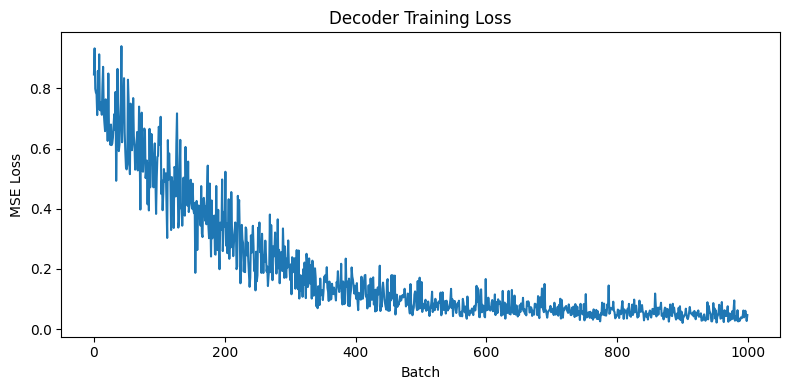

In [5]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Batch')
plt.ylabel('MSE Loss')
plt.title('Decoder Training Loss')
plt.tight_layout()
plt.show()

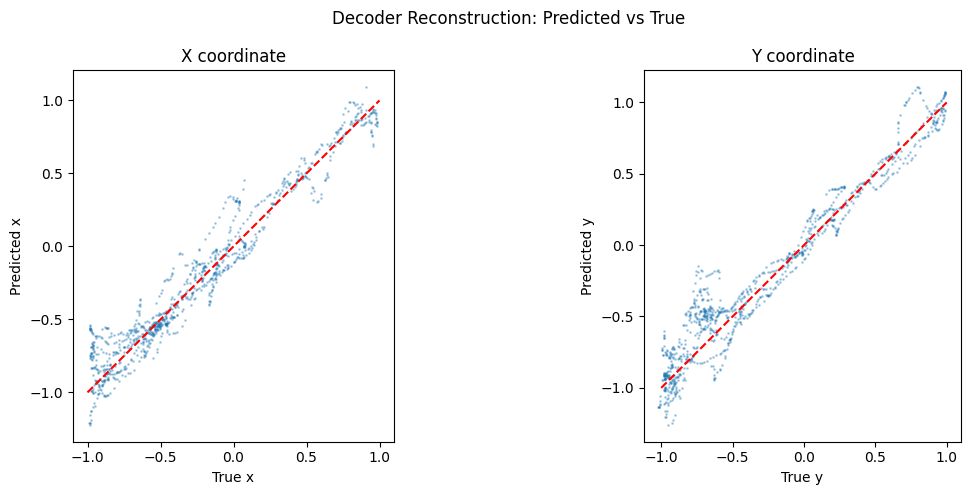

Eval MSE: 0.040565


In [6]:
# Evaluate on a held-out batch
import numpy as np
from nrt.helpers import encode

eval_batch = np.array(dataloader.get_batch(10000))  # batch not seen during training
V_eval = encode(g0, om, S, jnp.array(eval_batch))
B, L, D = V_eval.shape

V_flat = V_eval.reshape(B * L, D)
coords_true = eval_batch.reshape(B * L, 2)
coords_pred = np.array(model.apply(params, V_flat))

# Scatter: predicted vs true
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(coords_true[:, 0], coords_pred[:, 0], s=1, alpha=0.3)
axes[0].plot([-1, 1], [-1, 1], 'r--')
axes[0].set_xlabel('True x')
axes[0].set_ylabel('Predicted x')
axes[0].set_title('X coordinate')
axes[0].set_aspect('equal')

axes[1].scatter(coords_true[:, 1], coords_pred[:, 1], s=1, alpha=0.3)
axes[1].plot([-1, 1], [-1, 1], 'r--')
axes[1].set_xlabel('True y')
axes[1].set_ylabel('Predicted y')
axes[1].set_title('Y coordinate')
axes[1].set_aspect('equal')

plt.suptitle('Decoder Reconstruction: Predicted vs True')
plt.tight_layout()
plt.show()

mse = np.mean(np.sum((coords_pred - coords_true) ** 2, axis=-1))
print(f'Eval MSE: {mse:.6f}')